## Density Estimation in 1-dimensional Setting

This Jupyter notebook demonstrates how to use functions in `denest-kernelexpofam` to estimate density functions using the score matching loss function and visualize the resulting density estimates. 

The data used here are the eruption data from the Old Faithful geyser in Yellowstone National Park in Wyoming and were first published by [Azzalini and Bowman (1990)](https://www.jstor.org/stable/2347385?seq=1). The dataset consists of 299 observations collected continuously from August 1, 1985 to August 15, 1985, and contain 2 variables, namely, the `eruption` variable (the duration of this eruption) and the `waiting` variable (the waiting time for this eruption). Both variables are measured in the unit of minute. 

For the illustration purpose, we focus on the `waiting` variable only. 

We first import the modules needed. 

In [1]:
import os
import numpy as np
import pandas as pd

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *

from dekef.negloglik_gubasis import *
from dekef.negloglik_scorematchingbasis import *

from dekef.scorematching_common_functions import *
from dekef.scorematching_loss_function import *
from dekef.scorematching_penalized import *
from dekef.scorematching_earlystopping import *

from dekef.plot_density_1d import *

import warnings
warnings.filterwarnings('ignore')

### Load the data

In [2]:
os.chdir('/Users/chenxizhou/Dropbox/code_package/dekef/data')
true_data = np.load('geyser.npy').astype(np.float32)
waiting = true_data[:, 0].reshape(-1, 1)
xlimit = (21., 124.)
ylimit = (-0.001, 0.0701)

We now visualize the histogram of the `waiting` variable. 

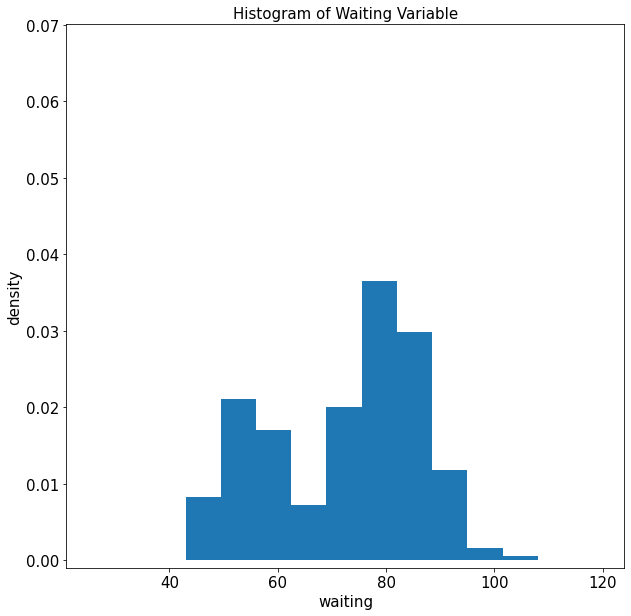

In [3]:
font_size = 15
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), bins = 'fd', density = True)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)

In the kernel exponential family, we use the Gaussian kernel function, and choose the bandwidth in the Gaussian kernel function to be $0.4$ times the median of pairwise distances of data. The median of pairwise distances of data can be computed using the `data_median_dist` function. 

In [4]:
bw_coef = 0.4
med_dist = data_median_dist(waiting.reshape(-1, 1))
bw = bw_coef * med_dist
kernel_function = GaussianPoly2(
    data = waiting, 
    r1 = 1.0, 
    r2 = 0., 
    c = 0., 
    bw = bw_coef * med_dist)

We choose the base density to be the probability density function of the Gamma distribution whose parameters are estimated by the method of the maximum likelihood. 

In [5]:
base_density = BasedenGamma(waiting)

### Penalized Score Matching Density Estimation

We now demonstrate how to estimate density functions using the penalized score matching density estimation method at a single penalty parameter $\lambda > 0$. The main function is `scorematching_penalized_coef`, which yields the coefficients of the basis functions in the natural parameter. 

In [6]:
# Here, we choose the penalty parameter to be exp(-6.0), supplied using the lambda_param argument. 
coef_smpen = scorematching_penalized_coef(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    lambda_param = np.exp(-6.0))

Next, we visualize the resulting score matching density estimate together with the histogram. The main function is `plot_density_1d`. Besides exihibiting the plot of the density estimate, this function also returns the points at which the density values are estimated and the resulting estimates. 

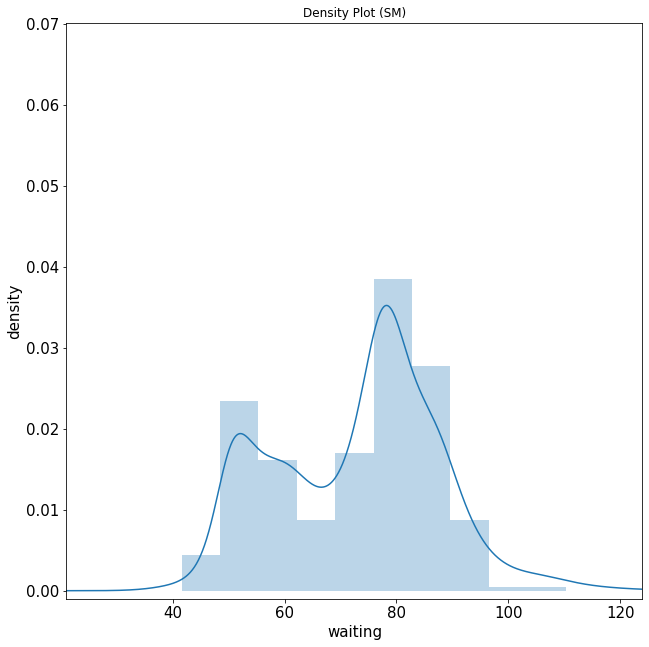

In [7]:
# a dict to specify the plotting parameters 
plot_kwargs = {'x_limit': xlimit, 
               'y_limit': ylimit,
               'plot_pts_cnt': 2000, 
               'figsize': 2000, 
               'den_color': 'tab:blue', 
               'hist_color': 'tab:blue', 
               'bins': 'fd', 
               'hist_alpha': 0.3, 
               'figsize': (10, 10), 
               'fontsize': 15}

# visualize density estimate
den_vals = plot_density_1d(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    coef = coef_smpen, 
    normalizing = True, 
    method = 'SM', 
    x_label = 'waiting',
    save_plot = False, 
    save_dir = None, 
    save_filename = None, 
    plot_kwargs = plot_kwargs)

It is typical that the best penalty paramter is unknown. With a list of penalty parameter candidates, we can use the cross validation to select the best one. The main function that does this is the ``scorematching_penalized_optlambda`` function, which returns the optimal penalty parameter and the coefficient vector of basis functions in the natural parameter of the density estimate. 

In [10]:
scorematching_penalized_optlambda(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    lambda_cand = np.exp(np.linspace(-10.0, -2.0, 9)), 
    k_folds = 3,
    save_dir = None, 
    save_info = False)

Lambda 0: 4.5399929762484854e-05


NotImplementedError: The kernel function should be one of 'gaussian_poly2' and 'rationalquad_poly2'.

In [9]:
np.linspace(-10.0, -2.0, 9)

array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.])

## Early Stopping Score Matching Density Estimation

In [ ]:
mm = scorematching_earlystopping_arbistep_update(
    data = waiting, 
    kernel_function = kernel_function, 
    base_density = base_density, 
    iter_num = 100, 
    step_size = 20, 
    threshold = 1e-8)